## Gridについて
jcope size (1082, 1191)<br>
jcope[time][LatGrid][LonGrid]<br>
もし，DataFrame型の場合，jcope[time][LonGrid][LatGrid]になるので注意！！！！

ais size (1051, 1191)<br>
ais[time][LonGrid][LatGrid]<br>
aisは信頼度が10^5以上（5桁）を使う

## import files

In [89]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm
import pickle as pkl
import math
import os 
import os.path as osp
import re

from utils import *
from kf_params import *

## データの読み込み

In [127]:
path_log = "./data/shipLog/中春"
filename = "curGridN_hours.pkl"
eachShip_n = pkl.load(open(osp.join(path_log, filename), 'rb'))

filename = "curGridE_hours.pkl"
eachShip_e = pkl.load(open(osp.join(path_log, filename), 'rb'))

filename = "cur_hours.csv"
shipLog = pd.read_csv(open(osp.join(path_log, filename), encoding="cp932",))


In [141]:
path_jcope = [fr'./data/eas/2015123031\2015123100{i}' for i in range(24)]

# JCOPE (MAP curN, curE)
jcope_n = []
for p in path_jcope:
    jcope_n.append(pd.read_csv(p+"/N.csv", encoding="cp932", header=None))
    jcope_n[-1] = jcope_n[-1].values
jcope_e = []
for p in path_jcope:
    jcope_e.append(pd.read_csv(p+"/E.csv", encoding="cp932", header=None))
    jcope_e[-1] = jcope_e[-1].values

In [151]:
ais_n = {}
ais_e = {}
ais_d = {}
path_ais = fr'./data/ais/2015123031'
patterns = ['(\w+){month:02}{day:02}..N.csv', '(\w+){month:02}{day:02}..E.csv', '(\w+){month:02}{day:02}..D.csv']
files = os.listdir(path_ais)
for d in dirs:
    path2 = osp.join(path, d, 'log')
    files = os.listdir(path2)
    filenames = [f for f in files if os.path.isfile(osp.join(path2, f))]
    for f in filenames:
        if re.match(patterns[0], f):
            f_path = osp.join(path2, f)
            time = int(f[15:-5])
            if not time in ais_n.keys():
                ais_n[time] = []
                ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_n[time][-1] = ais_n[time][-1].values
            else:
                ais_n[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_n[time][-1] = ais_n[time][-1].values         
        if re.match(patterns[1], f):
            f_path = osp.join(path2, f)
            time = int(f[15:-5])
            if not time in ais_e.keys():
                ais_e[time] = []
                ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_e[time][-1] = ais_e[time][-1].values
            else:
                ais_e[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_e[time][-1] = ais_e[time][-1].values        
        if re.match(patterns[2], f):
            f_path = osp.join(path2, f)
            time = int(f[15:-5])
            if not time in ais_d.keys():
                ais_d[time] = []
                ais_d[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_d[time][-1] = ais_e[time][-1].values
            else:
                ais_d[time].append(pd.read_csv(f_path, encoding="cp932", header=None))
                ais_d[time][-1] = ais_e[time][-1].values    

In [152]:
ais_n.keys()

dict_keys([])

## データの確認

In [144]:
datas = [eachShip_n[0], ais_n[0][0], ais_e[0][0], jcope_n[1], jcope_e[1]]
data_names = ['EachShip N', 'AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [1, 0], [1, 1], [2, 0], [2, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data, ax=axes[a, b])
plt.show()

KeyError: 0

In [145]:
shipLog

,Unnamed: 0,DtIdx,UTC,CurN,CurE,Grid0,Grid1,Lat,Lon
0,0,-9,2015/12/30 15,0.321099,-2.004484,625,564,32.686444,132.658444
1,1,-8,2015/12/30 15,0.367165,-0.920128,624,560,32.697959,132.547276
2,2,-7,2015/12/30 16,0.469927,-0.785755,619,554,32.831611,132.380909
3,3,-6,2015/12/30 17,0.576423,-0.332172,612,549,33.015017,132.259722
4,4,-5,2015/12/30 18,0.950580,-0.658371,606,544,33.183140,132.116197
5,5,-4,2015/12/30 19,0.268302,-0.551108,601,539,33.340529,131.976876
6,6,-3,2015/12/30 20,0.555998,-0.029995,594,534,33.517432,131.839835
7,7,-2,2015/12/30 21,-0.077818,0.031119,588,528,33.685717,131.676490
8,8,-1,2015/12/30 22,-0.099254,0.276694,586,519,33.761439,131.417197
9,9,0,2015/12/31 0,-0.046735,-0.046106,584,508,33.803399,131.102035


## データのチェック（グランドのデータでない，緯度経度のずれ）

In [146]:
# グランドのデータがあるかのチェック
time_set = shipLog['DtIdx']
deltaN = []
deltaE = []
grids = []
for time in time_set:
    data = shipLog[shipLog['DtIdx']==time]
    for i in range(len(data)):
        grid0 = data['Grid0'].values[i]
        grid1 = data['Grid1'].values[i]
        grids.append([grid0, grid1])
        if time>0:
            if jcope_n[time][grid0][grid1]==np.nan or jcope_n[time][grid0][grid1]==np.nan:
                print(f"{grid0}, {grid1} is ground position (time:{time})")
                continue
        deltaN.append(data['CurN'].values[i] - jcope_n[time][grid0][grid1])
        deltaE.append(data['CurE'].values[i] - jcope_e[time][grid0][grid1])

In [147]:
# 矢印とかにしてわかりやすく
def plot_target_points_mesh(grids, base_map=np.ones((1050, 1191))*nan_map[:1050], lineWidth=1, half_size=50):
    # ex) grids = [[10, 20], [15, 25]]
    a = np.array(base_map)
    size = a.shape
    for grid0, grid1 in grids:
        for i in range(lineWidth):
            #a[grid0+i][grid1-i:grid1+i] = [-2 for _ in range(2*i)]
            #a[grid0-i][grid1-i:grid1+i] = [-2 for _ in range(2*i)]
            a[grid0+i][:] = -2
            a[grid0-i][:] = -2
            a[:, grid1+i] = -2
            a[:, grid1-i] = -2
    grids_np = np.array(grids)
    grid0_min = np.min(grids_np.T[0])
    grid1_min = np.min(grids_np.T[1])
    grid0_max = np.max(grids_np.T[0])
    grid1_max = np.max(grids_np.T[1])
    box0 = [grid0_min-half_size, grid0_max+half_size]
    if box0[0] < 0:
        box0[0] = 0
    if size[0]<box0[1]:
        box0[1] = size[0]
    box1 = [grid1_min-half_size, grid1_max+half_size]
    if box1[0] < 0:
        box1[0] = 0
    if size[1]<box1[1]:
        box1[1] = size[1]
    b = a[box0[0]:box0[1]]
    b = b[:, box1[0]:box1[1]]
    sns.heatmap(b)
    plt.show()

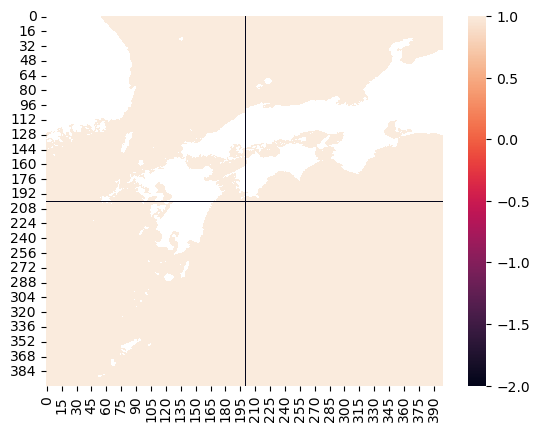

In [148]:
target = [[shipLog['Grid0'].values[0],  shipLog['Grid1'].values[0]]]
plot_target_points_mesh(target, half_size=200)

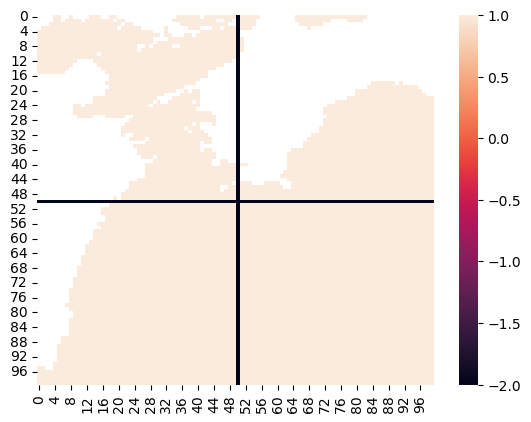

In [149]:
plot_target_points_mesh(target)

In [150]:
plot_target_points_mesh(target, base_map=ais_n[0][0])

KeyError: 0

In [ ]:
plot_target_points_mesh(target, base_map=jcope_n[0])

## 各データに対して誤差の計算

In [ ]:
#for i in range(len(shipLog)):
diff_ais_jcope = []
diff_ais_ship = []
diff_jcope_ship = []
dtidx = []
grids = []

for i in range(len(shipLog)):
    time = shipLog['DtIdx'].values[i]
    grid0 = shipLog['Grid0'].values[i]
    grid1 = shipLog['Grid1'].values[i]
    curN = shipLog['CurN'].values[i]
    curE = shipLog['CurE'].values[i]
    dtidx.append(time)
    grids.append([grid0, grid1])
    
    jcope_curN = np.nan
    jcope_curE = np.nan
    if time >= 0:
        if grid0<len(jcope_n[0]) and grid1<len(jcope_n[0][0]):
            jcope_curN = jcope_n[time][grid0][grid1]
            jcope_curE = jcope_e[time][grid0][grid1]

    ais_curN = np.nan
    ais_curE = np.nan
    if grid0<len(ais_n[0][0]) and grid1<len(ais_n[0][0][0]):
        if time in ais_n.keys(): 
            ais_curN = ais_n[time][0][grid0][grid1]
        if time in ais_e.keys():
            ais_curE = ais_e[time][0][grid0][grid1]

    diff_ais_jcope.append([ais_curN-jcope_curN, ais_curE-jcope_curE])
    diff_ais_ship.append([ais_curN-curN, ais_curE-curE])
    diff_jcope_ship.append([jcope_curN-curN, jcope_curE-curE])    


    #print('-------------------------')
    #print(f'Time: {time}, grid: ({grid0}, {grid1})')
    #print(f'Diff ais and jcope: {ais_curN-jcope_curN:.2}, {ais_curE-jcope_curE:.2}')
    #print(f'Diff ais and ship: {ais_curN-curN:.2}, {ais_curE-curE:.2}')
    #print(f'Diff jcope and ship: {jcope_curN-curN:.2}, {jcope_curE-curE:.2}')
    #print('-------------------------')

diff_results = pd.DataFrame([])
diff_results['DtIdx'] = dtidx

grids_np = np.array(grids)
diff_results['Grid0'] = grids_np.T[0]
diff_results['Grid1'] = grids_np.T[1]

a = np.array(diff_ais_jcope)
diff_results['AIS-JCOPE_N'] = a.T[0] 
diff_results['AIS-JCOPE_E'] = a.T[1] 

a = np.array(diff_ais_ship)
diff_results['AIS-Ship_N'] = a.T[0] 
diff_results['AIS-Ship_E'] = a.T[1] 

a = np.array(diff_jcope_ship)
diff_results['JCOPE-Ship_N'] = a.T[0] 
diff_results['JCOPE-Ship_E'] = a.T[1] 

diff_results

In [ ]:
tf = diff_results['AIS-JCOPE_N']==diff_results['AIS-JCOPE_N']
data = diff_results[tf]
diff_ais_jcope_n = np.sqrt(np.sum(data['AIS-JCOPE_N']*data['AIS-JCOPE_N'])/len(data))
tf = diff_results['AIS-JCOPE_E']==diff_results['AIS-JCOPE_E']
data = diff_results[tf]
diff_ais_jcope_e = np.sqrt(np.sum(data['AIS-JCOPE_E']*data['AIS-JCOPE_E'])/len(data))

tf = diff_results['AIS-Ship_N']==diff_results['AIS-Ship_N']
data = diff_results[tf]
diff_ais_ship_n = np.sqrt(np.sum(data['AIS-Ship_N']*data['AIS-Ship_N'])/len(data))
tf = diff_results['AIS-Ship_E']==diff_results['AIS-Ship_E']
data = diff_results[tf]
diff_ais_ship_e = np.sqrt(np.sum(data['AIS-Ship_E']*data['AIS-Ship_E'])/len(data))

tf = diff_results['JCOPE-Ship_N']==diff_results['JCOPE-Ship_N']
data = diff_results[tf]
diff_jcope_ship_n = np.sqrt(np.sum(data['JCOPE-Ship_N']*data['JCOPE-Ship_N'])/len(data))
tf = diff_results['JCOPE-Ship_E']==diff_results['JCOPE-Ship_E']
data = diff_results[tf]
diff_jcope_ship_e = np.sqrt(np.sum(data['JCOPE-Ship_E']*data['JCOPE-Ship_E'])/len(data))


print('-------------------------')
print(f'AIS-JCOPE: {diff_ais_jcope_n:.2f}, {diff_ais_jcope_e:.2f}')
print(f'AIS-Ship: {diff_ais_ship_n:.2f}, {diff_ais_ship_e:.2f}')
print(f'JCOPE-Ship: {diff_jcope_ship_n:.2f}, {diff_jcope_ship_e:.2f}')
print('-------------------------')